# Fence segmentation

In [1]:
import cv2
from skimage.morphology import dilation as sk_dilation
import torch
from torch.utils.data import Dataset
import pytorch_lightning as pl
import segmentation_models_pytorch as smp
import pytorch_lightning as pl
import os
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import functional as F
from pytorch_lightning.loggers import CSVLogger
import pandas as pd
import matplotlib.pyplot as plt
from pytorch_lightning.callbacks import EarlyStopping
from torch.utils.data import DataLoader


from PIL import Image
from scipy.ndimage import distance_transform_edt

pl.seed_everything(42)

Seed set to 42


42

In [2]:
def dilate_mask(mask, k=3):
    m = mask[0].numpy()
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    m = cv2.dilate(m, kernel, iterations=1)
    return torch.from_numpy(m).unsqueeze(0)

class FenceSegmentationDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None, training=True):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms
        self.training = training
        self.image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(".jpg")])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        base = os.path.splitext(img_name)[0]

        image = Image.open(os.path.join(self.images_dir, img_name)).convert("RGB")
        mask = Image.open(os.path.join(self.labels_dir, base + ".png")).convert("L")

        if self.transforms:
            image, mask = self.transforms(image, mask)

        if mask.ndim == 3:
            mask = mask[:1]   # keep only first channel
        
        # if self.training:
        #     mask = dilate_mask(mask, k=3)

        # Ensure binary mask
        mask = (mask > 0.5).float()

        return {
            "image": image,
            "mask": mask,
            "filename": img_name
        }

In [3]:
def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    num = 2 * (pred * target).sum(dim=(2,3))
    den = pred.sum(dim=(2,3)) + target.sum(dim=(2,3)) + eps
    return 1 - (num / den).mean()

class FenceSegmentationLightning(pl.LightningModule):
    def __init__(self, learning_rate=3e-4):
        super().__init__()
        self.save_hyperparameters()
        self.model = smp.Unet(
            encoder_name="resnet50",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1
        )
        self.bce = torch.nn.BCEWithLogitsLoss()
    
    def forward(self, x):
        return self.model(x)
    
    def shared_step(self, batch):
        x = batch["image"]
        y = batch["mask"]
        logits = self(x)
        loss_bce = self.bce(logits, y)
        loss_dice = dice_loss(logits, y)
        loss = 0.5 * loss_bce + 0.5 * loss_dice
        return loss
    
    def training_step(self, batch, batch_idx):
        loss = self.shared_step(batch)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self.shared_step(batch)
        # FIXED: Changed from "train_loss" to "val_loss"
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

In [15]:
csv_logger = CSVLogger(
    save_dir=os.getcwd(),
    name="fence_segmentation_logs"
)

# Early stopping callback
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    mode="min",
    verbose=True
)

train_transforms = T.Compose([
    T.Resize(256, antialias=True),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(p=0.5),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transforms = T.Compose([
    T.Resize(256, antialias=True),
    T.CenterCrop(224),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_dataset = FenceSegmentationDataset(
    images_dir="dataset/Training Set/Training_Images",
    labels_dir="dataset/Training Set/Training_Labels",
    transforms=train_transforms
)

val_dataset = FenceSegmentationDataset(
    images_dir="dataset/Test Set/Test_Images",
    labels_dir="dataset/Test Set/Test_Labels",
    transforms=val_transforms,
    training=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

model = FenceSegmentationLightning(learning_rate=3e-4)

# Trainer with early stopping callback
trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices="auto",
    logger=csv_logger,
    callbacks=[early_stop_callback]
)

trainer.fit(model, train_loader, val_loader)
trainer.save_checkpoint("defence/fence_segmentation.ckpt")

log_csv_path = os.path.join(csv_logger.log_dir, "metrics.csv")
print("Metrics saved to:", log_csv_path)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | Unet              | 32.5 M | train
1 | bce   | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
32.5 M    Trainable params
0         Non-trainable params
32.5 M    Total params
130.084   Total estimated model params size (MB)
224       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved. New best score: 0.333


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 5 records. Best score: 0.071. Signaling Trainer to stop.


Metrics saved to: /home/alumno/Desktop/datos/Computer Vision/Final-Computer-Vision/fence_segmentation_logs/version_2/metrics.csv


   epoch  step  train_loss  val_loss
0      0    68    0.511266  0.333421
1      1   137    0.275568  0.224499
2      2   206    0.174986  0.146908
3      3   275    0.125366  0.122214
4      4   344    0.099655  0.105336


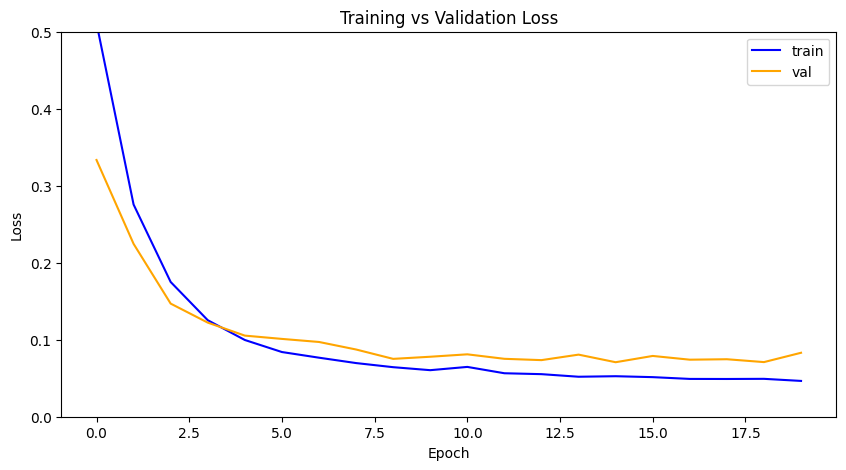

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

metric_df = pd.read_csv('fence_segmentation_logs/version_2/metrics.csv')
metric_df = metric_df.groupby('epoch', as_index=False).first()
print(metric_df.head())

f, ax = plt.subplots(1, 1, figsize=(10, 5))
metric_df.train_loss.plot(ax=ax, color='blue', label='train')
metric_df.val_loss.plot(ax=ax, color='orange', label='val')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_ylim([0,0.5]) 
ax.set_title('Training vs Validation Loss')
ax.legend()
plt.show()




In [23]:
ckpt_path = "fence_segmentation_logs/version_2/checkpoints/epoch=19-step=1380.ckpt"

model = FenceSegmentationLightning.load_from_checkpoint(ckpt_path)
model.eval()
model.cuda()  # remove if running on CPU

FenceSegmentationLightning(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          

In [9]:
import matplotlib.pyplot as plt
import numpy as np

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225])

def denormalize(img: torch.Tensor):
    """
    img: Tensor [3, H, W], normalized
    returns: Tensor [3, H, W] in range [0, 1]
    """
    mean = IMAGENET_MEAN[:, None, None]
    std = IMAGENET_STD[:, None, None]
    return img * std + mean

def visualize_prediction_with_error(model, dataset, index=0, threshold=0.5):
    device = next(model.parameters()).device
    sample = dataset[index]

    image = sample["image"].unsqueeze(0).to(device)
    gt_mask = sample["mask"]

    with torch.no_grad():
        logits = model(image)
        probs = torch.sigmoid(logits)
        pred_mask = (probs > threshold).float()

    # --- denormalize image ---
    img = denormalize(image[0].cpu()).clamp(0, 1)
    img_np = img.permute(1, 2, 0).numpy()

    gt = gt_mask[0].cpu().numpy()
    pred = pred_mask[0, 0].cpu().numpy()

    # --- error map ---
    error = (gt != pred)

    # --- overlay incorrect pixels in red ---
    error_overlay = img_np.copy()
    error_overlay[error] = [1.0, 0.0, 0.0]

    # ---- Plot ----
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))

    axs[0].imshow(img_np)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(gt, cmap="gray")
    axs[1].set_title("Ground Truth Mask")
    axs[1].axis("off")

    axs[2].imshow(pred, cmap="gray")
    axs[2].set_title("Predicted Mask")
    axs[2].axis("off")

    axs[3].imshow(error_overlay)
    axs[3].set_title("Errors (Red = Incorrect)")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()

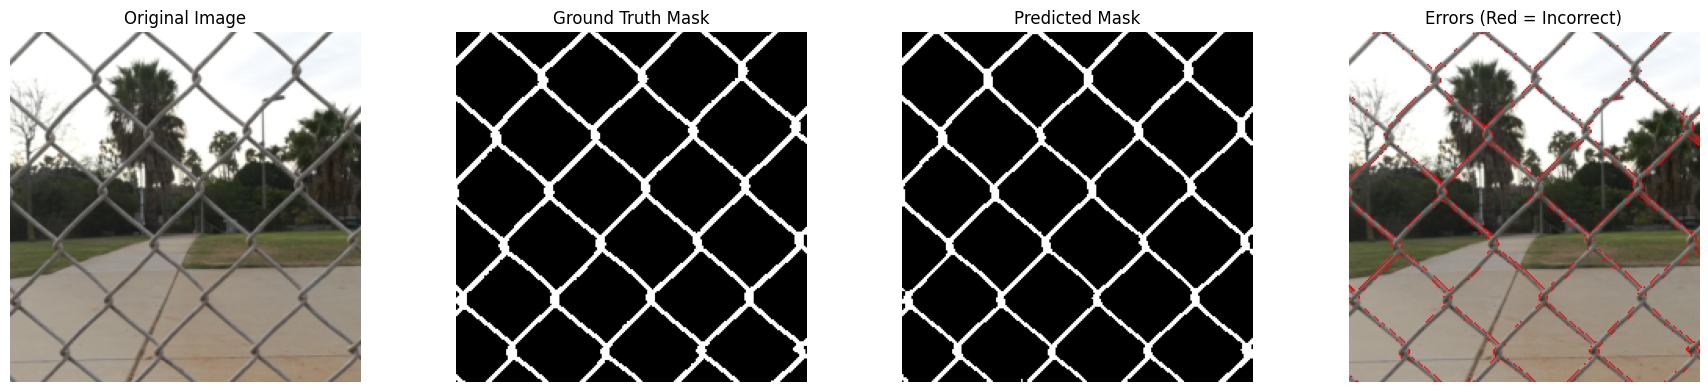

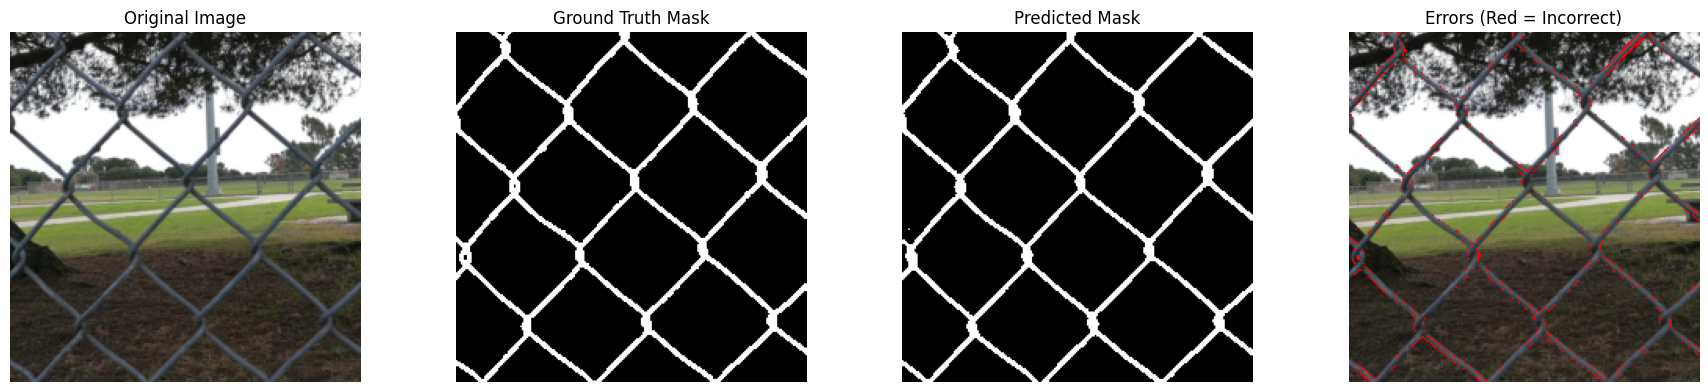

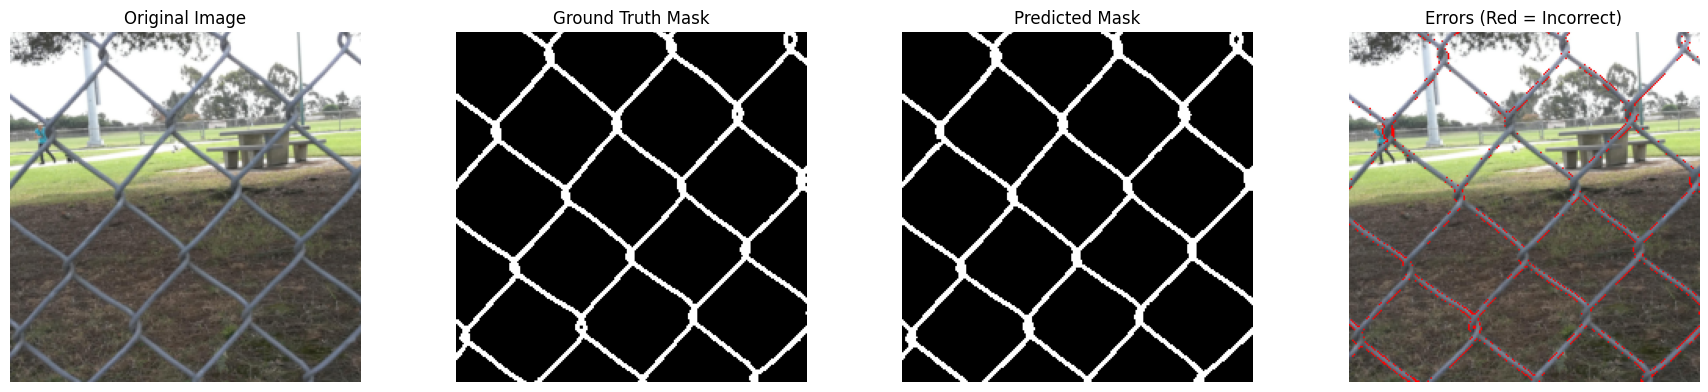

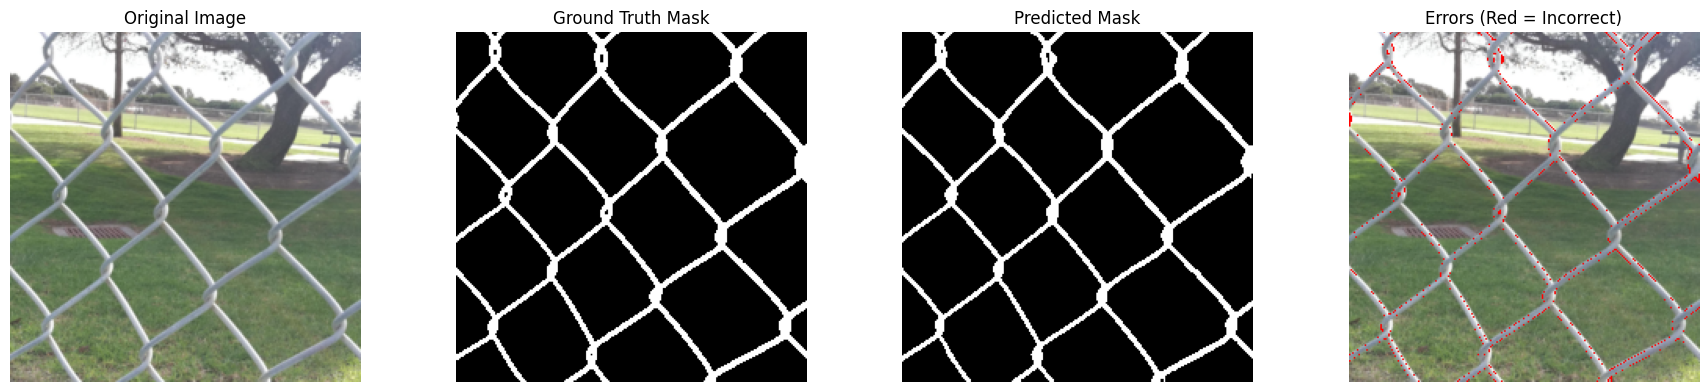

In [25]:
import random

num_examples = 4
indices = random.sample(range(len(val_dataset)), num_examples)

for idx in indices:
    visualize_prediction_with_error(model, val_dataset, index=idx)


# Segmentation by patches

In [4]:
ckpt_path = "fence_segmentation_logs/version_2/checkpoints/epoch=19-step=1380.ckpt"

model = FenceSegmentationLightning.load_from_checkpoint(ckpt_path)
model.eval()
model.cuda()  # remove if running on CPU

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

FenceSegmentationLightning(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          

In [11]:
val_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_dataset = FenceSegmentationDataset(
    images_dir="dataset/Test Set/Test_Images",
    labels_dir="dataset/Test Set/Test_Labels",
    transforms=val_transforms,
    training=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

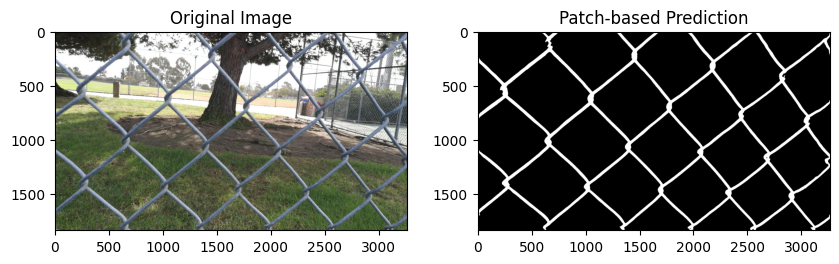

In [19]:
import torch.nn.functional as F

def predict_in_patches(model, image_tensor, patch_size=224):
    """
    Performs segmentation by dividing the image into patches.
    image_tensor: Shape [3, H, W]
    """
    model.eval()
    c, h, w = image_tensor.shape
    
    # 1. Check if the image is big enough
    if h < patch_size or w < patch_size:
        print(f"Image dimensions ({h}x{w}) are smaller than patch size ({patch_size}). Resizing...")
        image_tensor = T.Resize((patch_size, patch_size))(image_tensor)
        h, w = patch_size, patch_size

    # Prepare output mask (initialized with zeros)
    full_mask = torch.zeros((1, h, w)).to(image_tensor.device)
    # To handle overlaps, you could use a weight mask, but here we assume no overlap for simplicity
    
    # 2. Iterate through patches
    with torch.no_grad():
        for i in range(0, h, patch_size):
            for j in range(0, w, patch_size):
                # Handle edge cases where the last patch might go out of bounds
                # Adjusting coordinates to ensure we always take a patch_size window
                y_start = min(i, h - patch_size)
                x_start = min(j, w - patch_size)
                
                patch = image_tensor[:, y_start:y_start+patch_size, x_start:x_start+patch_size]
                patch = patch.unsqueeze(0).to(model.device) # Add batch dimension
                
                # Model prediction
                logits = model(patch)
                probs = torch.sigmoid(logits)
                
                # Insert patch back into the full mask
                full_mask[:, y_start:y_start+patch_size, x_start:x_start+patch_size] = probs.squeeze(0)

    return (full_mask > 0.5).float()

def predict_with_overlap(model, image_tensor, patch_size=224, stride=112):
    model.eval()
    
    # Identify the device the model is currently on
    model_device = next(model.parameters()).device
    
    c, h, w = image_tensor.shape
    
    # Initialize accumulation masks on the same device as the model
    full_mask = torch.zeros((1, h, w), device=model_device)
    count_mask = torch.zeros((1, h, w), device=model_device)

    # Ensure the input image tensor is on the correct device
    image_tensor = image_tensor.to(model_device)

    with torch.no_grad():
        for i in range(0, h - patch_size + 1, stride):
            for j in range(0, w - patch_size + 1, stride):
                # Extract patch (it's already on model_device now)
                patch = image_tensor[:, i:i+patch_size, j:j+patch_size].unsqueeze(0)
                
                # Get prediction
                logits = model(patch)
                probs = torch.sigmoid(logits)
                
                # Accumulate
                full_mask[:, i:i+patch_size, j:j+patch_size] += probs.squeeze(0)
                count_mask[:, i:i+patch_size, j:j+patch_size] += 1

    # Average the overlapping results
    final_mask = full_mask / count_mask.clamp(min=1)
    return (final_mask > 0.5).float()

def predict_resized(model, image_tensor):
    model.eval()
    # Resize big image down to what the model saw in training
    original_size = image_tensor.shape[-2:]
    small_img = T.Resize((224, 224))(image_tensor).unsqueeze(0).to(next(model.parameters()).device)
    
    with torch.no_grad():
        logits = model(small_img)
        mask = torch.sigmoid(logits)
    
    # Resize mask back up to original image size
    final_mask = T.Resize(original_size)(mask)
    return (final_mask > 0.5).float()

def predict_with_context_halo(model, image_tensor, patch_size=224, stride=112, halo_size=224):
    """
    patch_size: the size of the final square we want to fill in the mask
    halo_size: how much extra context to grab around the patch (on each side)
    """
    model.eval()
    model_device = next(model.parameters()).device
    
    c, h, w = image_tensor.shape
    
    # Pad the original image so we can grab context even at the very edges
    # padding is (left, right, top, bottom)
    img_padded = torch.nn.functional.pad(image_tensor, (halo_size, halo_size, halo_size, halo_size), mode='reflect')
    
    full_mask = torch.zeros((1, h, w), device=model_device)
    count_mask = torch.zeros((1, h, w), device=model_device)

    with torch.no_grad():
        for i in range(0, h, stride):
            for j in range(0, w, stride):
                # Ensure we don't go out of bounds for the base coordinates
                i_safe = min(i, h - patch_size)
                j_safe = min(j, w - patch_size)
                
                # 1. Extract the 'Halo' patch from the padded image
                # In the padded image, the original (0,0) is now at (halo_size, halo_size)
                y_start = i_safe 
                x_start = j_safe
                y_end = i_safe + patch_size + (2 * halo_size)
                x_end = j_safe + patch_size + (2 * halo_size)
                
                large_patch = img_padded[:, y_start:y_end, x_start:x_end]
                
                # 2. Resize context patch down to model input size (224x224)
                # This provides the "zoomed out" view
                input_patch = T.Resize((224, 224))(large_patch).unsqueeze(0).to(model_device)
                
                # 3. Predict
                logits = model(input_patch)
                probs = torch.sigmoid(logits)
                
                # 4. Resize mask back to the context size
                mask_patch_large = T.Resize((patch_size + 2*halo_size, patch_size + 2*halo_size))(probs)
                
                # 5. Crop out the center (removing the halo) to get the sharp patch
                center_mask = mask_patch_large[:, :, halo_size:halo_size+patch_size, halo_size:halo_size+patch_size]
                
                # 6. Accumulate
                full_mask[:, i_safe:i_safe+patch_size, j_safe:j_safe+patch_size] += center_mask.squeeze(0)
                count_mask[:, i_safe:i_safe+patch_size, j_safe:j_safe+patch_size] += 1

    final_mask = full_mask / count_mask.clamp(min=1)
    return (final_mask > 0.5).float()


# Example usage with a sample from val_dataset
sample = val_dataset[15]
img = sample["image"]
patch_mask = predict_with_context_halo(model, img)

# Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(denormalize(img).permute(1, 2, 0).cpu().numpy())
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(patch_mask.squeeze().cpu().numpy(), cmap='gray')
plt.title("Patch-based Prediction")
plt.show()